In [1]:
# !pip install segmentation-models-pytorch
# !pip install torchmetrics
# !pip install mlflow[databricks]

In [2]:
import os

# Replace with your actual workspace URL and token
# os.environ['DATABRICKS_HOST'] = ""
# os.environ['DATABRICKS_TOKEN'] = ""


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# from torchmetrics.segmentation import DiceScore
# from torchmetrics.segmentation import MeanIoU

from tqdm import tqdm
import json

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image, mask, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    # image = cv2.imread(image_path)
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# dataset = '/content/drive/MyDrive/Documentos/UniAndes/MAIA/2026-12/Proyecto Despluiegue de Soluciones/Proyecto/Scoliosis_Dataset'
# indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))

In [7]:
# dataset = 'Scoliosis_Dataset'
project_path = 'C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA'
dataset_version = 'Scoliosis_Dataset_v2'
dataset = os.path.join(project_path, dataset_version)
indice = pd.read_csv('indice_completas.csv')
normal = indice[indice['grupo']=='Normal']
esc = indice[indice['grupo']=='Scoliosis']

In [8]:
with open(dataset+os.sep+'diccionario_etiquetas_T1_T12_L1_L5.json', 'r') as f:
    dic_labels = json.load(f)

color_label = dic_labels['mascara_multiclase_color_rgb']

In [9]:
# Split: 80% entrenamiento, 10% validación y 10% prueba
train_normal, test_normal = train_test_split(
    normal, test_size=0.1, random_state=42
)

train_normal, val_normal = train_test_split(
    train_normal, test_size=0.1, random_state=42
)

train_esc, test_esc = train_test_split(
    esc, test_size=0.1, random_state=42
)

train_esc, val_esc = train_test_split(
    train_esc, test_size=0.1, random_state=42
)

train = pd.concat([train_normal, train_esc])
train['split'] = 'train'
val = pd.concat([val_normal, val_esc])
val['split'] = 'val'
test = pd.concat([test_normal, test_esc])
test['split'] = 'test'

data_split = pd.concat([train, val, test])

In [10]:
data_split['image_relpath']=dataset_version+os.sep+data_split['ruta_radiografia']
data_split['mask_relpath']=dataset_version+os.sep+data_split['ruta_mascara_multiclase_id_png']

In [11]:
# imagenes = pd.DataFrame(columns=['image_path', 'mask_path', 'id_paciente'])
# imagenes['image_path'] = dataset +os.sep + indice['grupo'] + os.sep + indice['imagen']
# imagenes['mask_path'] = dataset + os.sep + indice['ruta_mascara_multiclase_id_png']
# imagenes['id_paciente'] = indice['id_paciente']
# masks_path = masks_path.apple(dataset, indice['grupo'], indice['ruta_mascara_multiclase_id_png'])

In [12]:
# imagenes

In [13]:
train = data_split[data_split['split'] == 'train']
val = data_split[data_split['split'] == 'val']
test = data_split[data_split['split'] == 'test']

In [14]:
train_img = project_path+os.sep+train['image_relpath'].reset_index(drop=True)
train_mask = project_path+os.sep+train['mask_relpath'].reset_index(drop=True)
val_img = project_path+os.sep+val['image_relpath'].reset_index(drop=True)
val_mask = project_path+os.sep+val['mask_relpath'].reset_index(drop=True)
test_img = project_path+os.sep+test['image_relpath'].reset_index(drop=True)
test_mask = project_path+os.sep+test['mask_relpath'].reset_index(drop=True)

In [15]:
print(f'Train: {train_img.shape} Val: {val_img.shape} Test: {test_img.shape}')

Train: (60,) Val: (8,) Test: (8,)


In [16]:
MODEL_NAME = 'Unet++'
MODEL_PATH = 'modelos'+os.sep+MODEL_NAME+'patch'+'completas'+'.pth'
SEED = 42
NUM_EPOCHS = 100
BATCH_SIZE = 4
PATIENCE = 50
STRIDE = 4
LR = 1e-3                   # Learning rate
WD = 0                   # Weight Decay
DROPOUT = None
PATCH_SIZE = 128
NUM_PATCHES = 8
CROP_RATIO = (0.1, 0.5)
STRIDE_RATIO = 4
IN_CHANNELS = 3
NUM_CLASSES = 18
TRAIN_ENCODER = True
CENTER_IMAGES = True
CLAHE = True
PERSPECTIVE = True

# LOSS = 'CrossEntropyLoss'
LOSS = 'CombinedLoss'
# LOSS = 'CombinedLossFocal'
# LOSS = 'DiceLoss'

# ENCODER_NAME = "resnet34"
# ENCODER_NAME = "resnet152"
ENCODER_NAME = "efficientnet-b7"
# ENCODER_NAME = "mit_b5"
# ENCODER_NAME = "tu-swinv2_small_window16_256"
# ENCODER_NAME = 'tu-sam2_hiera_large'

ENCODER_WEIGHTS = "imagenet"
# ENCODER_WEIGHTS = True
# ENCODER_WEIGHTS = None

# DECODER_ATTENTION = 'scse'
DECODER_ATTENTION = None

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

if IN_CHANNELS == 1:
  MEAN = 0.44531356896770125
  STD = 0.2692461874154524

# CE_WEIGHT = 0.5
# DICE_WEIGHT = 0.5
# BASE_CHANNELS = 32

In [17]:
import mlflow

# Set the tracking URI to the Databricks workspace
mlflow.set_tracking_uri("databricks")

# Set the experiment name (must start with /Users/<email>/ or /Shared/)
experiment = mlflow.set_experiment("/"+MODEL_NAME+'_patch')

In [18]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = np.sum(np.logical_and(pred_cls==1,target_cls==1))
        union = np.sum(np.logical_or(pred_cls==1,target_cls==1))

        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice)
        iou_scores.append(iou)

    if average:
        return np.mean(dice_scores), np.mean(iou_scores)
    else:
        return dice_scores, iou_scores

In [19]:
def compute_metrics_torch(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    num_classes = num_classes

    # Convert targets to one-hot: [N, C, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    preds_one_hot = torch.nn.functional.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()

    # Calculate intersection and cardinality
    dims = (2, 3) # Sum over batch, height, and width
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    union = torch.sum(preds_one_hot + targets_one_hot, dim=dims) - intersection

    dice_score = (2. * intersection + eps) / (torch.sum(preds_one_hot, dim=dims) + torch.sum(targets_one_hot, dim=dims) + eps)
    iou_score = (intersection + eps) / (union + eps)

    if average:
        return dice_score.mean(dim=1), iou_score.mean(dim=1)
    else:
        return dice_score, iou_score

In [20]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [N, C, H, W], targets: [N, H, W]
        num_classes = logits.shape[1]
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Convert targets to one-hot: [N, C, H, W]
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and cardinality
        dims = (0, 2, 3) # Sum over batch, height, and width
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        union = torch.sum(probs + targets_one_hot, dim=dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean() # Return mean loss across classes

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=1, dice_weight=1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        # self.dice = DiceLoss()
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

class CustomWeightedFocalLoss(nn.Module):
    def __init__(self, alpha_weights, gamma=2.0):
        super().__init__()
        # Esperamos un tensor 1D puro de tamaño [18]
        self.alpha_weights = alpha_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        # 1. Calculamos la Cross Entropy SIN pesos para obtener la probabilidad real (pt)
        # reduction='none' mantiene la forma [Batch, H, W]
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        # 2. Aplicamos la fórmula base de Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # 3. EL TRUCO MAGNÍFICO: Mapeo de pesos
        # targets contiene la clase correcta (0-17) de cada píxel.
        # Al hacer esto, extraemos el peso exacto para cada píxel individual,
        # creando un tensor 'pixel_weights' de forma idéntica: [Batch, H, W]
        pixel_weights = self.alpha_weights[targets]

        # 4. Multiplicamos de forma segura (ambos tensores son [Batch, H, W]) y promediamos
        weighted_focal_loss = focal_loss * pixel_weights

        return weighted_focal_loss.mean()

class CombinedLossFocal(nn.Module):
    def __init__(self, fl_weight=1, dice_weight=1):
        super().__init__()

        class_frequencies = np.array([1.0, 0.9718875502008032, 0.9879518072289156, 0.9919678714859438, 0.9879518072289156, 0.9759036144578314, 0.9558232931726908, 0.9317269076305221, 0.9116465863453815, 0.8955823293172691, 0.8714859437751004, 0.7991967871485943, 0.7590361445783133, 0.6546184738955824, 0.6265060240963856, 0.5502008032128514, 0.4819277108433735, 0.44176706827309237]
        )

        # 2. Calcular Alpha usando frecuencia inversa suavizada (Raíz cuadrada)
        # Agregamos un pequeño epsilon (1e-5) para evitar división por cero
        # alpha = 1.0 / np.sqrt(class_frequencies + 1e-5)
        #
        # # 3. Normalizar los alphas para que no den números gigantes que exploten el gradiente
        # alpha = alpha / np.sum(alpha)
        #
        # # alpha=torch.tensor(alpha, dtype=torch.float32).to(device)
        # alpha = torch.tensor(alpha, dtype=torch.float32).to(device)

        alpha = None

        self.focal = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0) if alpha == None else CustomWeightedFocalLoss(alpha_weights=alpha, gamma=2.0)
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.fl_weight = fl_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        fl_loss = self.focal(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.fl_weight * fl_loss + self.dice_weight * dice_loss

In [21]:
class CustomSegmentationDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None, num_patches=NUM_PATCHES):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform
        self.num_patches = num_patches

    def __len__(self):
        return len(self.images_filenames)

    def __getpath__(self, idx):
        return self.images_filenames[idx]

    def __getitem__(self, idx):
        image_path = self.images_filenames[idx]
        mask_path = self.masks_filenames[idx]
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

            patches_img = []
            patches_mask = []
            for _ in range(self.num_patches):
                if self.transform:
                    augmented = self.transform(image=image, mask=mask)
                    p_image = augmented['image']
                    p_mask = augmented['mask']

                    patches_img.append(p_image)
                    patches_mask.append(p_mask)

            stacked_images = torch.stack(patches_img)
            stacked_masks = torch.stack(patches_mask)

        except:
            new_idx = (idx + 1)
            return self.__getitem__(new_idx)


        return stacked_images, stacked_masks

In [22]:
# --- TRANSFORMACIONES (Albumentations) ---
normalization = A.Normalize(mean=MEAN, std=STD)
clahe = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)

# Transformaciones de entrenamiento: redimensionamiento, aumento de datos y normalización
train_transforms = []
# train_transforms += [A.OneOf([A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=0.8), A.RandomCrop(height=PATCH_SIZE, width=PATCH_SIZE, p=0.2)], p=1)]
train_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1), A.GaussNoise(std_range=(0.05, 0.1), p=1.0)]


train_transforms+=[
    A.HorizontalFlip(p=0.2),
    A.Rotate(limit=(-10, 10), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5)
]

if PERSPECTIVE:
    train_transforms.append(A.Perspective(scale=(0.01, 0.05)))
if CLAHE:
    train_transforms.append(clahe)

train_transforms.append(normalization)
train_transforms.append(ToTensorV2())

train_transform = A.Compose(train_transforms)
# train_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.HorizontalFlip(p=0.2),
#     A.Rotate(limit=(-10, 10), p=1.0),
#     # A.VerticalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Normalize(mean=MEAN, std=STD),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

# Transformaciones de validación/prueba: solo redimensionamiento y normalización
val_transforms = []

# val_transforms += [A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=1)]
val_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1)]
if CLAHE:
    val_transforms.append(clahe)

val_transforms.append(normalization)
val_transforms.append(ToTensorV2())

val_transform = A.Compose(val_transforms)

test_transforms = []
if CLAHE:
    test_transforms.append(clahe)
# test_transforms.append(ToTensorV2())
test_transforms.append(normalization)
test_transforms = A.Compose(test_transforms)



In [23]:

# --- DATALOADERS ---
train_dataset = CustomSegmentationDataset(train_img, train_mask, transform=train_transform)
val_dataset = CustomSegmentationDataset(val_img, val_mask, transform=val_transform)
test_dataset = CustomSegmentationDataset(test_img, test_mask, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# print(f"Imágenes de entrenamiento: {len(train_dataset)}")
# print(f"Imágenes de validación: {len(val_dataset)}")

torch.Size([3, 128, 128])


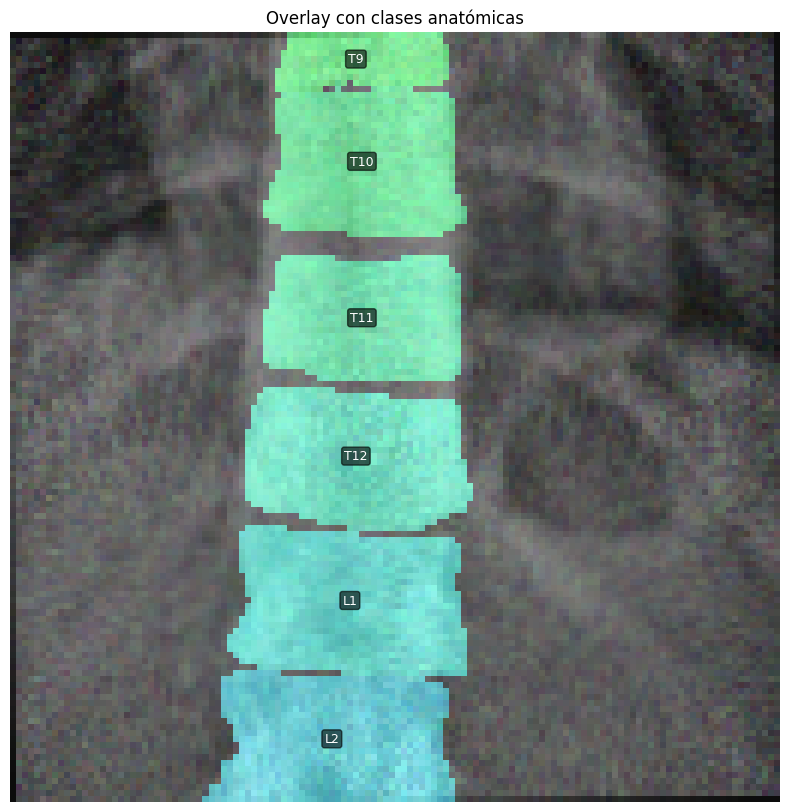

In [24]:
image, mask = train_dataset.__getitem__(10)
print(image[0].shape)
image = image[0].permute(1, 2, 0).cpu().numpy()
mask = mask[0].squeeze().cpu().numpy()
show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

torch.Size([8, 3, 128, 128])


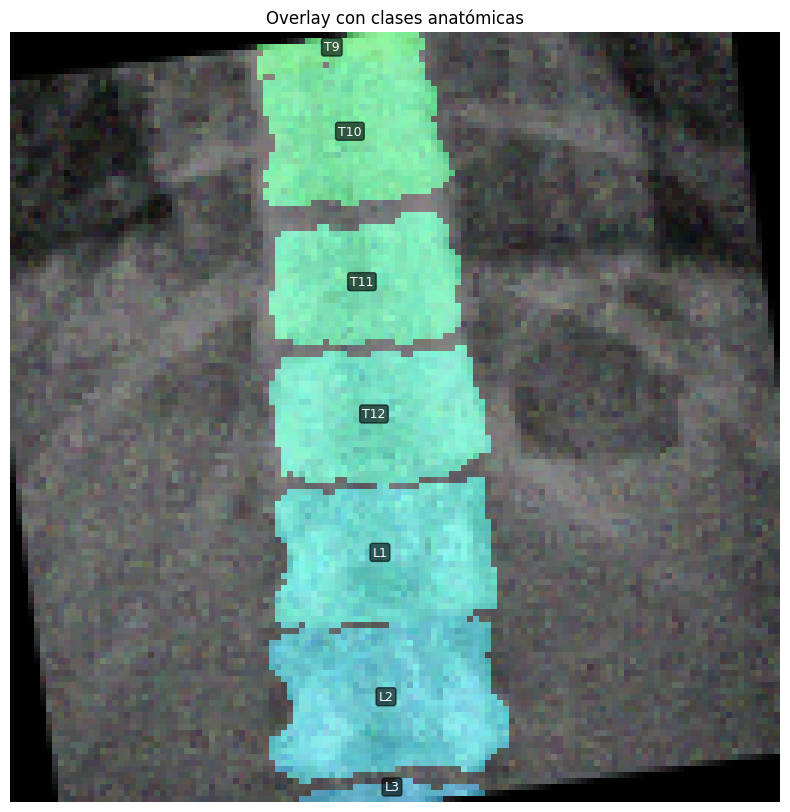

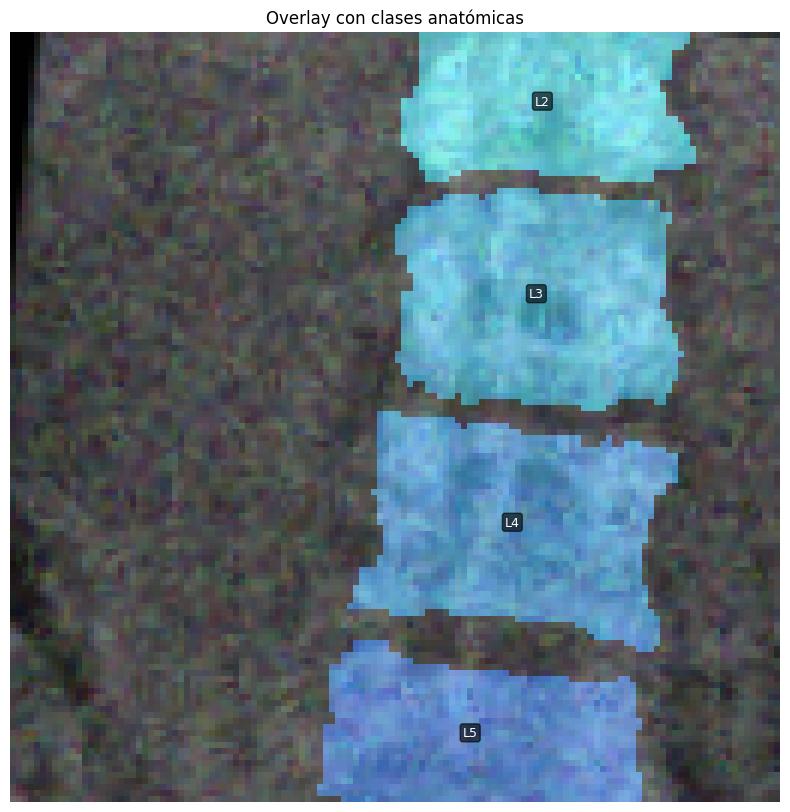

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


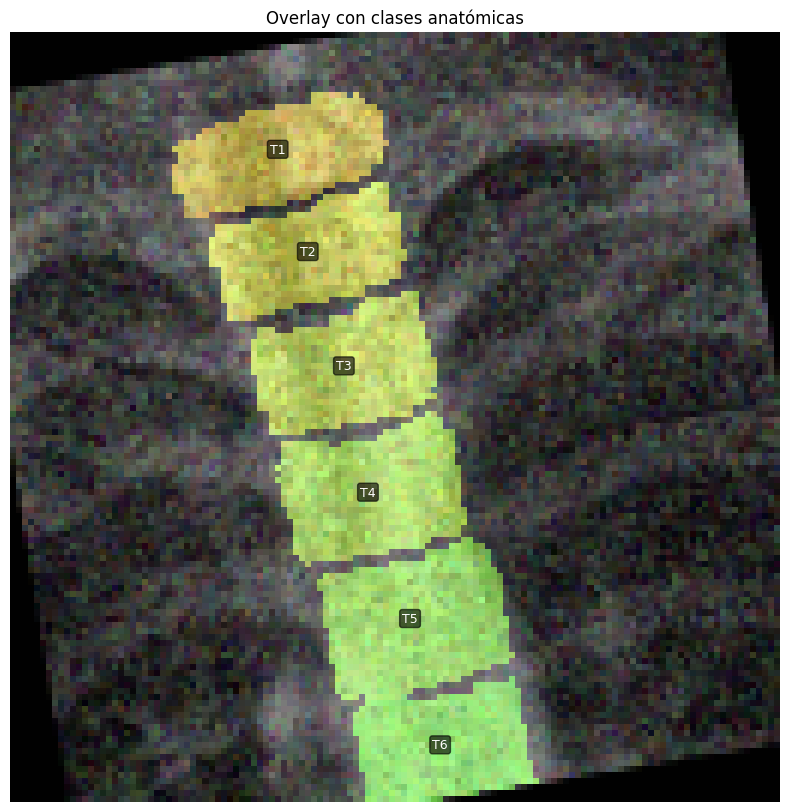

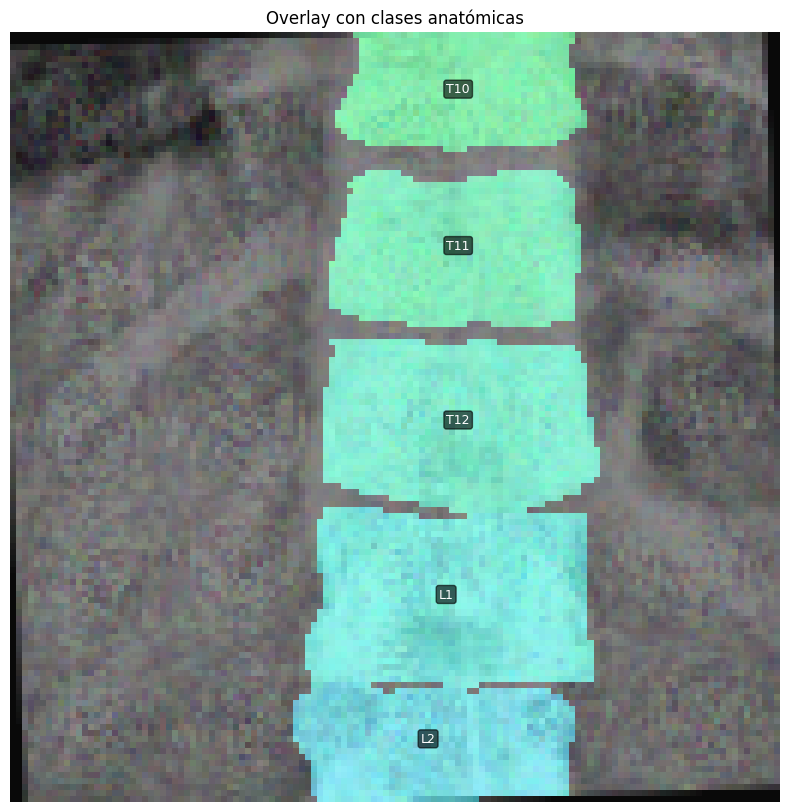

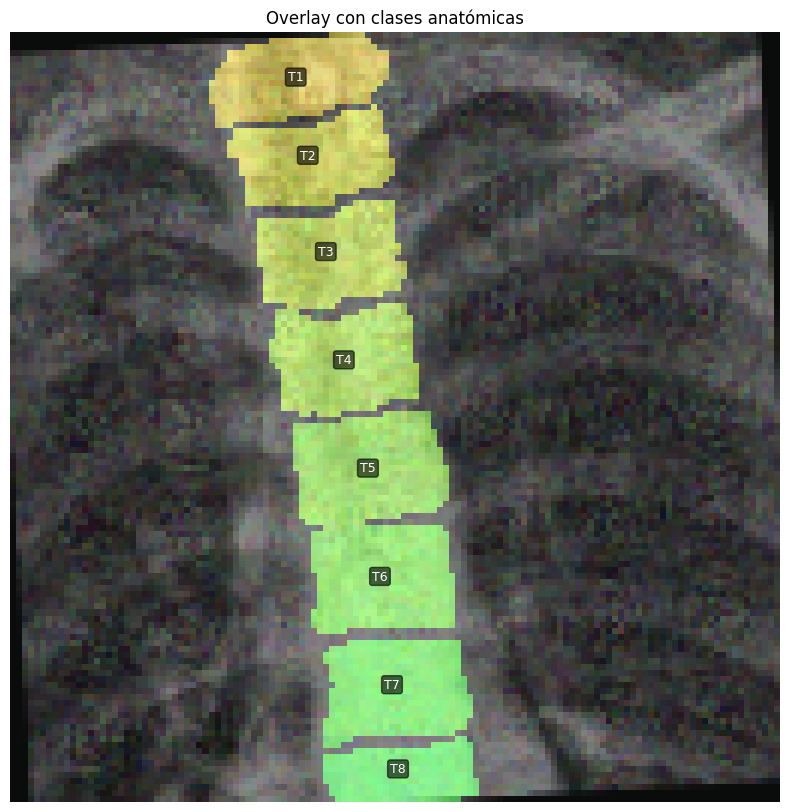

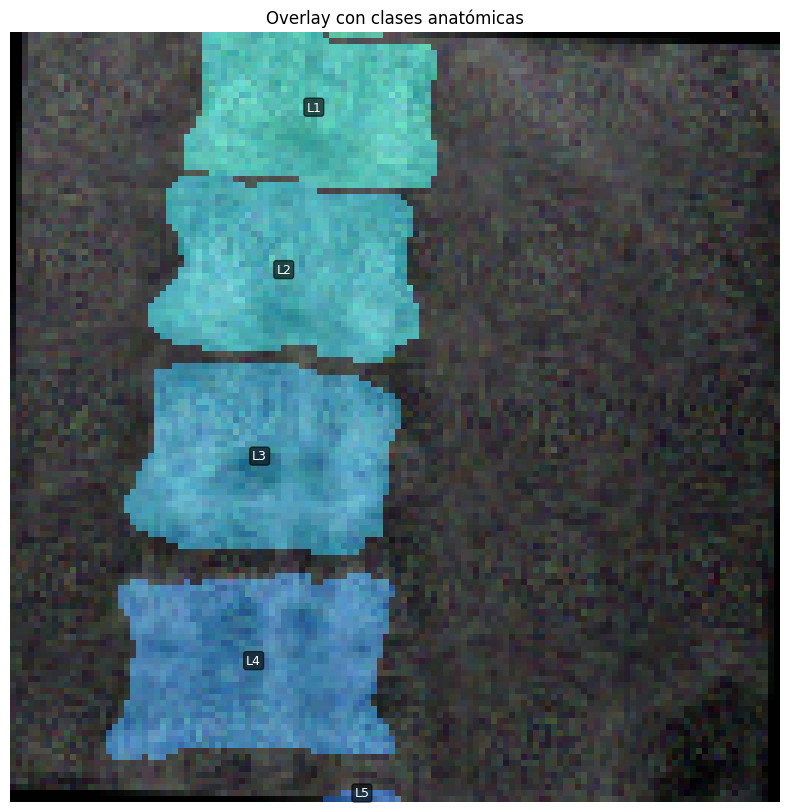

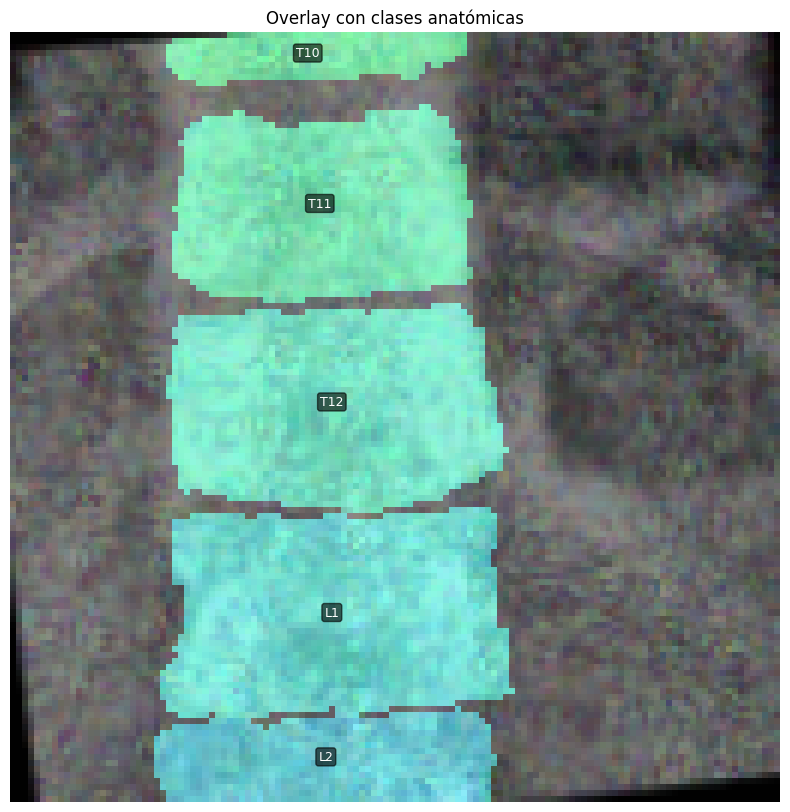

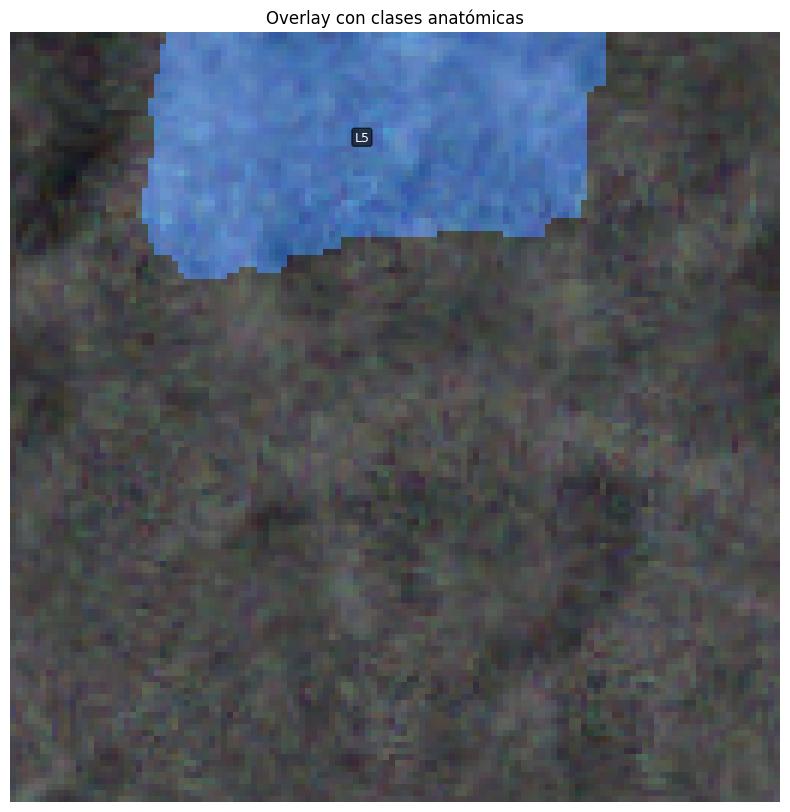

In [25]:
images, masks = train_dataset.__getitem__(10)
print(images.shape)
for image, mask in zip(images, masks):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

In [26]:
if MODEL_NAME == 'Unet++':
    model = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )
elif MODEL_NAME == 'Segformer':
    model = smp.Segformer(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        # aux_params={'classes':NUM_CLASSES, 'dropout':0.2}
    )
if MODEL_NAME == 'U-net':
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )

if MODEL_NAME == 'DeepLabV3+':
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=IN_CHANNELS,
            classes=NUM_CLASSES,
            # decoder_attention_type = DECODER_ATTENTION,
            # pooling='max',
            # dropout = 0.5
        )

if DROPOUT is not None:
        model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT), model.segmentation_head)
model = model.to(device)

# Definir la función de pérdida y el optimizador
# Usamos BCEWithLogitsLoss porque el modelo no tiene una capa sigmoide final por defecto
# criterion = nn.BCEWithLogitsLoss()

if LOSS == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()

elif LOSS == 'DiceLoss':
    # criterion =  DiceLoss()
    criterion = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

elif LOSS == 'CombinedLoss':
    criterion = CombinedLoss()

elif LOSS == 'CombinedLossFocal':
        criterion = CombinedLossFocal()

elif LOSS == 'FocalLoss':
        criterion = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

if not TRAIN_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False


# Definir el scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',    # 'min' porque quieres que la pérdida disminuya
    factor=0.1,    # Reduce el LR al 10% (multiplica por 0.1)
    patience=PATIENCE,    # Espera 5 épocas sin mejora antes de reducir
    threshold=1e-4, # Cambio mínimo para considerar que hay mejora
)

In [ ]:
with mlflow.start_run(experiment_id=experiment.experiment_id):

    train_losses = np.zeros(NUM_EPOCHS)
    val_losses = np.zeros(NUM_EPOCHS)
    val_dice = np.zeros(NUM_EPOCHS)
    best_epoch = 0
    best_metric = 0
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)

            images, masks = images.float().to(device), masks.long().to(device) # <--- Asegurar .long()


            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)

            # pred_mask = torch.argmax(outputs, dim=1)
            loss = criterion(outputs, masks)
            # loss = criterion(pred_mask, masks)

            # Backward pass y optimización
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validación simple
        model.eval()
        val_loss = 0.0
        dice_score_val = torch.empty((0,NUM_CLASSES))
        IoU_score_val = torch.empty((0,NUM_CLASSES))
        with torch.no_grad():
            for images, masks in val_loader:
                B, N, C, H, W = images.shape
                images = images.view(B*N, C, H, W)
                masks = masks.view(B * N, H, W).to(device)
                images, masks = images.float().to(device), masks.long().to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                # loss = criterion(pred_mask, masks)
                val_loss += loss.item()

                pred_mask = torch.argmax(outputs, dim=1)

                dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
                dice_score_val = torch.cat((dice_score_val, dice), dim=0)
                IoU_score_val = torch.cat((IoU_score_val, IoU), dim=0)
            dice_score_val = torch.mean(dice_score_val)
            IoU_score_val = torch.mean(IoU_score_val)

        if dice_score_val > best_metric and epoch > 15:
            best_metric = dice_score_val
            torch.save(model.state_dict(), MODEL_PATH)
            best_epoch = epoch + 1

        train_losses[epoch] = train_loss / len(train_loader)
        val_losses[epoch] = val_loss / len(val_loader)

        scheduler.step(val_loss/len(val_loader))
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val DICE Score: {dice_score_val:.4f} | Val IoU Score: {IoU_score_val:.4f}")

    print('Best Epoch: ', best_epoch, ' Best metric: ', best_metric)

    mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'LR': LR, 'WD': WD,'CROP_RATIO':CROP_RATIO, 'STRIDE_RATIO': STRIDE_RATIO ,'PATCH_SIZE': PATCH_SIZE,'NUM_PATCHES':NUM_PATCHES , 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})

    mlflow.log_metric(f"val_mean_dice_score", dice_score_val)
    mlflow.log_metric(f"best_val_dice_score", dice_score_val)
    mlflow.pytorch.log_model(model, name=MODEL_NAME)

    for step, value in enumerate(train_losses):
        mlflow.log_metric('train_hist', value, step=step)
    for step, value in enumerate(val_losses):
        mlflow.log_metric('val_hist', value, step=step)


Epoch 1/250 | Train Loss: 3.6759 | Val Loss: 3.3278 | Val DICE Score: 0.1557 | Val IoU Score: 0.1456
Epoch 2/250 | Train Loss: 2.5338 | Val Loss: 2.0370 | Val DICE Score: 0.5540 | Val IoU Score: 0.5474
Epoch 3/250 | Train Loss: 1.9225 | Val Loss: 1.8069 | Val DICE Score: 0.6155 | Val IoU Score: 0.6094
Epoch 4/250 | Train Loss: 1.7119 | Val Loss: 1.6350 | Val DICE Score: 0.5967 | Val IoU Score: 0.5891
Epoch 5/250 | Train Loss: 1.6406 | Val Loss: 1.6210 | Val DICE Score: 0.5911 | Val IoU Score: 0.5819
Epoch 6/250 | Train Loss: 1.5818 | Val Loss: 1.5049 | Val DICE Score: 0.6487 | Val IoU Score: 0.6387
Epoch 7/250 | Train Loss: 1.5206 | Val Loss: 1.3896 | Val DICE Score: 0.6715 | Val IoU Score: 0.6595
Epoch 8/250 | Train Loss: 1.5060 | Val Loss: 1.4238 | Val DICE Score: 0.6116 | Val IoU Score: 0.5988
Epoch 9/250 | Train Loss: 1.4674 | Val Loss: 1.6697 | Val DICE Score: 0.6124 | Val IoU Score: 0.5972
Epoch 10/250 | Train Loss: 1.3461 | Val Loss: 1.3615 | Val DICE Score: 0.6575 | Val IoU Sco

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

In [ ]:
# plt.figure()
# plt.plot(train_losses, label="Train Loss")
# plt.plot(val_losses, label="Val Loss")
# plt.xlabel('Epochs')
# plt.legend()

In [ ]:
def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels_images(
    image,
    gt_mask,
    pred_mask,
    label_dict,
    alpha=0.45,
    min_pixels=20
):

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    if image.shape[2] == 1:
        image_cmap = "gray"
    else:
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN
    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title(f"Predicción con etiquetas, Dice={dice_score_mean:.4f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    # print(f'Dice Score promedio: {dice_score_mean:.4f}')
    # print('Dice Score por clase: ')
    # for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
    #     # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
    #     print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
import cv2
from tqdm import tqdm
import scipy

def create_gaussian_window(patch_size, sigma=1.0):
    """
    Crea una matriz de pesos 2D con una distribución Gaussiana.
    Da más peso al centro del parche y menos a los bordes.
    """
    window_1d = scipy.signal.windows.gaussian(patch_size,sigma)
    window_2d = np.outer(window_1d,window_1d)
    return torch.from_numpy(window_2d).float()

def patch_based_inference(model, image, mask, patch_size, stride, num_classes, sigma, show_patches=False):
    """
    Realiza inferencia en una imagen grande usando ventanas deslizantes con solape y suavizado.

    image: Tensor [C, H_large, W_large] pre-procesado (normalizado).
    """
    model.eval()
    H_large, W_large, _ = image.shape

    # 1. Crear tensores vacíos en la GPU para acumular las predicciones y los pesos
    # Forma: [Num_Clases, H, W]
    # Usamos floats para acumular probabilidades
    accumulated_predictions = torch.zeros((num_classes, H_large, W_large)).to(device)
    accumulated_weights = torch.zeros((H_large, W_large)).to(device)

    # 2. Crear la ventana Gaussiana de suavizado
    gaussian_window = create_gaussian_window(patch_size, sigma).to(device)

    # 3. Bucle de Ventana Deslizante (Sliding Window)
    # Calculamos cuántos pasos dar en y y x
    y_steps = range(0, H_large - patch_size + 1, stride)
    x_steps = range(0, W_large - patch_size + 1, stride)

    # print(len(x_steps), W_large, patch_size,stride)

    # Asegurar que cubrimos el borde final si el stride no encaja perfecto
    # (Añadimos el último parche posible si no termina exactamente en el borde)

    if y_steps[-1] + patch_size < H_large:
        y_steps = list(y_steps) + [H_large - patch_size]
    if x_steps[-1] + patch_size < W_large:
        x_steps = list(x_steps) + [W_large - patch_size]

    # print(len(x_steps), W_large, patch_size,stride)
    with torch.no_grad():
        # Usamos tqdm para ver progreso ya que esto tarda
        # image = (image / 255.0 - MEAN) / STD
        # for y in tqdm(y_steps, desc="Procesando filas"):
        for y in y_steps:
            for x in x_steps:
                # Extaer el parche de la imagen grande

                # print(image_norm.shape)
                # HWC a CHW y convertir a Tensor
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))

                # transform = torchvision.transforms.ToTensor()
                # patch = transform(patch)
                patch = torch.from_numpy(patch)
                patch = patch.permute(2, 0, 1)
                # print(patch.shape)

                # Añadir dimensión de batch -> [1, C, H_patch, W_patch]
                patch_batch = patch.float().unsqueeze(0).to(device)
                # print(patch_batch.shape)

                # Inferencia del modelo (Logits) -> [1, 18, H_patch, W_patch]
                # trans_image = val_transform(image=image)['image'].float().unsqueeze(0).to(device)
                logits = model(patch_batch)

                if show_patches:
                    patched_mask = mask[y:y+patch_size, x:x+patch_size]
                    patched_mask = cv2.resize(patched_mask, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_NEAREST)
                    pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
                    # print(patch.shape, patched_mask.shape, pred_mask_patch.shape)
                    show_gt_vs_pred_with_labels_images(
                    patch.permute(1, 2, 0).cpu().numpy(),
                    patched_mask,
                    pred_mask_patch,
                    label_dict=dic_labels,
                    alpha=0.45,
                    min_pixels=20
                )

                # pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
                # plt.figure()
                # plt.imshow((patch.permute(1, 2, 0).cpu().numpy())*STD + MEAN)
                # plt.imshow(patch.permute(1, 2, 0).cpu().numpy())
                # plt.figure()
                # plt.imshow(pred_mask_patch)
                # show_overlay_with_labels(patch.permute(1, 2, 0).cpu().numpy(), pred_mask_patch, dic_labels) # Plot patches preds
                # print(np.max(pred_mask_patch), np.min(pred_mask_patch))

                # Convertir logits a probabilidades (Softmax)
                # Esto es crucial para la fusión ponderada
                # probs = F.softmax(logits, dim=1).squeeze(0) # -> [18, H_patch, W_patch]
                probs = F.softmax(logits, dim=1) # -> [1, 18, H_patch, W_patch]
                probs = F.interpolate(probs, size=(patch_size, patch_size), mode='bilinear', align_corners=False).squeeze(0)

                # 4. Aplicar Fusión Ponderada en la GPU
                # Multiplicar las probabilidades de cada clase por el peso Gaussiano
                weighted_probs = probs * gaussian_window.unsqueeze(0) # Broadcatsing de canales

                # Acumular en la imagen grande
                accumulated_predictions[:, y:y+patch_size, x:x+patch_size] += weighted_probs

                # Acumular los pesos aplicados en esa zona para luego normalizar
                accumulated_weights[y:y+patch_size, x:x+patch_size] += gaussian_window

    # 5. Normalización Final
    # Dividir las probabilidades acumuladas por la suma de pesos en cada píxel
    # Usamos una pequeña constante (1e-5) para evitar división por cero en bordes extremos
    final_segmentation_probs = accumulated_predictions / (accumulated_weights.unsqueeze(0) + 1e-5)

    return final_segmentation_probs


def patch_inference(model, image, mask, patch_area = CROP_RATIO[1], stride=STRIDE_RATIO, num_classes=NUM_CLASSES, sigma=1.0, show_patches=False):
    x, y, _ = image.shape
    min_dim = min(x, y)
    patch_size = np.round(np.sqrt(patch_area*x*y)).astype(int)
    patch_size = min_dim if patch_size > min_dim else patch_size
    stride = np.round(patch_size/stride).astype(int)
    # print(f'Patch Size: {patch_size} | Stride: {stride}')

    probs_map = patch_based_inference(
    model,
    image,
    mask,
    patch_size,
    stride,
    num_classes,
    sigma,
    show_patches
    )
    pred_mask = torch.argmax(probs_map, dim=0).cpu().numpy() # -> [H, W] con valores 0-17
    # print(f"Forma de máscara final: {final_mask.shape}", f"Forma imagen original: {image.shape}")
    return pred_mask

In [ ]:
# best_mean_dice = 0
# best_sigma = 0
# for sigma in tqdm(np.linspace(1, 50, 10),desc='Realizando predicciones en parche para el set de validacion'):
#     mean_dice = 0
#     for idx in range(len(val_img)):
#         img_path = val_img[idx]
#         mask_path = val_mask[idx]
#         image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#         image = test_transforms(image=image)['image']
#         pred_mask = patch_inference(model, image, mask, sigma=sigma)
#
#         if idx == 0:
#             show_gt_vs_pred_with_labels_images(
#             image,
#             mask,
#             pred_mask,
#             label_dict=dic_labels,
#             alpha=0.45,
#             min_pixels=20
#         )
#         # plt.figure()
#         # plt.imshow(cv2.resize(image*STD+MEAN,(pred_mask.shape[1],pred_mask.shape[0])))
#         # plt.figure()
#         # plt.imshow(pred_mask)
#         # plt.figure()
#         # plt.imshow(cv2.resize(mask,(pred_mask.shape[1],pred_mask.shape[0])))
#
#         dice, IoU = compute_metrics(pred_mask, mask)
#         mean_dice += dice
#
#     mean_dice = mean_dice/len(val_img)
#     print(f'Sigma: {sigma} | Mean Dice: {mean_dice:.4f}')
#
#     if best_mean_dice < mean_dice:
#         best_mean_dice = mean_dice
#         best_sigma = sigma
#
# print(f'Best Sigma: {best_sigma} | Best Dice: {best_mean_dice:.4f}')

In [ ]:
# best_crop = 0
# best_global_mean_dice = 0
# best_global_sigma = 0
# for crop in tqdm(np.linspace(CROP_RATIO[0], CROP_RATIO[1], 11),desc='Gridsearch crop size y sigma'):
#     best_mean_dice = 0
#     best_sigma = 0
#     for sigma in tqdm(np.linspace(5, 50, 11),desc='Realizando predicciones en parche para el set de validacion'):
#         mean_dice = 0
#         for idx in range(len(val_img)):
#             img_path = val_img[idx]
#             mask_path = val_mask[idx]
#             image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#             mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#             image = test_transforms(image=image)['image']
#             pred_mask = patch_inference(model, image, mask, patch_area=crop, sigma=sigma)
#
#             # if idx == 0:
#             #     show_gt_vs_pred_with_labels_images(
#             #     image,
#             #     mask,
#             #     pred_mask,
#             #     label_dict=dic_labels,
#             #     alpha=0.45,
#             #     min_pixels=20
#             # )
#
#             dice, IoU = compute_metrics(pred_mask, mask)
#             mean_dice += dice
#
#         mean_dice = mean_dice/len(val_img)
#         print(f'Current CropRatio: {crop} | Current Sigma: {sigma} | Mean Dice: {mean_dice:.4f}')
#
#         if best_mean_dice < mean_dice:
#             best_mean_dice = mean_dice
#             best_sigma = sigma
#
#     print(f'Current CropRatio: {crop} | Best Sigma: {best_sigma} | Mean Dice: {best_mean_dice:.4f}')
#
#     if best_global_mean_dice < best_mean_dice:
#         best_global_mean_dice = best_mean_dice
#         best_crop = crop
#         best_global_sigma = sigma
#
# print(f'Results --> Best Crop: {best_crop} |Best sigma: {best_global_sigma}| Best Dice: {best_global_mean_dice:.4f}')

In [ ]:
# SIGMA = best_global_sigma

best_crop = 0.26
SIGMA = 36.5

In [ ]:
# best_mean_dice = 0
# best_stride = 0
# for stride in tqdm(np.linspace(2,6,3),desc='Busqueda stride'):
#     for idx in range(len(val_img)):
#         img_path = val_img[idx]
#         mask_path = val_mask[idx]
#         image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#         image = test_transforms(image=image)['image']
#         pred_mask = patch_inference(model, image, mask, stride=stride, patch_area=best_crop, sigma=SIGMA)
#
#         # if idx == 0:
#         #     show_gt_vs_pred_with_labels_images(
#         #     image,
#         #     mask,
#         #     pred_mask,
#         #     label_dict=dic_labels,
#         #     alpha=0.45,
#         #     min_pixels=20
#         # )
#
#         dice, IoU = compute_metrics(pred_mask, mask)
#         mean_dice += dice
#
#     mean_dice = mean_dice/len(val_img)
#     print(f'Current Stride: {stride} | Mean Dice: {mean_dice:.4f}')
#
#     if best_mean_dice < mean_dice:
#         best_mean_dice = mean_dice
#         best_stride = stride
#
# print(f'Results --> Best Stride: {best_stride}| Best Dice: {best_mean_dice:.4f}')

In [ ]:
# STRIDE=best_stride
STRIDE=4

In [ ]:
# Predicciones del modelo para la imagen reconstruida
dice_score_test = 0
IoU_score_test = 0
model.eval()
for idx in range(len(val_img)):
        img_path = val_img[idx]
        mask_path = val_mask[idx]
        image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = test_transforms(image=image)['image']
        pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA)
        # print(image.shape)
        dice, IoU = compute_metrics(pred_mask, mask)
        dice_score_test += dice
        IoU_score_test += IoU

dice_score_test = dice_score_test/len(val_img)
IoU_score_test = IoU_score_test/len(val_img)

print(f'Mean Dice Score: {dice_score_test} | Mean IoU score: {IoU_score_test}')

In [ ]:
# Predicciones dle modelo usando parches
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            # print(image.shape)
            N, C, H, W = image.shape
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            # print(image.shape)
            for image, mask, pred_mask in zip(image, mask, pred_mask):
                # print(image.shape)
                dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy(), average=False)
            dice_score_test += dice

dice_score_test = dice_score_test/len(test_dataset)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [ ]:
# Predicciones del modelo para la imagen reconstruida
dice_score_test = np.zeros(NUM_CLASSES)
IoU_score_test = np.zeros(NUM_CLASSES)
model.eval()
for idx in range(len(test_img)):
        img_path = test_img[idx]
        mask_path = test_mask[idx]
        image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = test_transforms(image=image)['image']
        pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA)
        # print(image.shape)
        dice, IoU = compute_metrics(pred_mask, mask, average=False)
        dice_score_test += dice
        IoU_score_test += IoU

dice_score_test = dice_score_test/len(test_img)
IoU_score_test = IoU_score_test/len(test_img)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

print(f'Mean Dice Score: {np.mean(dice_score_test)} | Mean IoU score: {np.mean(IoU_score_test)}')

In [ ]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [ ]:
# Pruebas funcion compute_metrics_torch con el dataset test
dice_score_test = torch.zeros(NUM_PATCHES, NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).cpu()
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), mask.to(torch.long).cpu(), average=False)
            dice_score_test += dice.squeeze(0)

dice_score_test = dice_score_test/len(test_dataset)
print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')


for i,j in zip(dic_labels['mascara_multiclase_id_png'], torch.mean(dice_score_test, dim=0)):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
# Pruebas funcion compute_metrics_torch con el dataloader test
dice_score_test = torch.empty((0,18))
with torch.no_grad():
        for images, masks in test_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)
            images, masks = images.float().to(device), masks.long().to(device)
            # print(images.shape, masks.shape)
            outputs = model(images)
            pred_mask = torch.argmax(outputs, dim=1)
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            # print(dice.shape)
            dice_score_test = torch.cat((dice_score_test, dice), dim=0)

print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')
mean_dice_score = torch.mean(dice_score_test, dim=0).numpy()

for i,j in zip(dic_labels['mascara_multiclase_id_png'], mean_dice_score):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    patch_idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    print(dataset.__getpath__(idx))

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_tensor = image_tensor[patch_idx]
    gt_mask = gt_mask[patch_idx]
    image_batch = image_tensor.float().unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)
    # print(logits)
    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    # dice_score = DiceScore(num_classes=NUM_CLASSES, average="none", input_format='index')
    # dice_score_mean = DiceScore(num_classes=NUM_CLASSES, average="macro", input_format='index')
    # dice_score_mean = dice_score_mean(pred_mask, gt_mask.to(torch.long).cpu())
    # sample_dice = dice_score(pred_mask, gt_mask.to(torch.long).cpu())

    pred_mask = pred_mask.numpy()
    gt_mask = gt_mask.cpu().numpy()

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN
    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title("Predicción con etiquetas")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)
    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    print(f'Dice Score promedio: {dice_score_mean:.4f}')
    print('Dice Score por clase: ')
    for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
        # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
        print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')
    # print(f"DICE Score: {sample_dice:.4f}")

    # print("\nClases presentes en Ground Truth:")
    # for c in gt_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")
    #
    # print("\nClases presentes en Predicción:")
    # for c in pred_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")

In [ ]:
import random
# Seleccionar un índice aleatorio del dataset de test
idx = 2
# print(idx)
for patch_idx in range(NUM_PATCHES):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = patch_idx,
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

In [ ]:
import random
# Seleccionar un índice aleatorio del dataset de test
# idx = random.randint(0, len(test_dataset) - 1)
# print(idx)
for idx in range(len(test_dataset)):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = random.randint(0, NUM_PATCHES-1),
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

In [ ]:
# Visualización predicciones test con reconstrucción de máscara
model.eval()
for idx in range(len(test_img)):
        img_path = test_img[idx]
        mask_path = test_mask[idx]
        image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = test_transforms(image=image)['image']
        pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA)
        # print(image.shape)
        show_gt_vs_pred_with_labels_images(
            image,
            mask,
            pred_mask,
            label_dict=dic_labels,
            alpha=0.45,
            min_pixels=20
        )


In [ ]:
model.eval()
idx=37
img_path = test_img[idx]
mask_path = test_mask[idx]
image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
image = test_transforms(image=image)['image']
pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA, show_patches=True)
# print(image.shape)
show_gt_vs_pred_with_labels_images(
    image,
    mask,
    pred_mask,
    label_dict=dic_labels,
    alpha=0.45,
    min_pixels=20
)

In [ ]:
model.eval()
idx=35
img_path = test_img[idx]
mask_path = test_mask[idx]
image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
image = test_transforms(image=image)['image']
pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA, show_patches=True)
# print(image.shape)
show_gt_vs_pred_with_labels_images(
    image,
    mask,
    pred_mask,
    label_dict=dic_labels,
    alpha=0.45,
    min_pixels=20
)